100%|██████████| 262k/262k [00:00<00:00, 14.4MB/s]

Extracting files...
Dataset path: /root/.cache/kagglehub/datasets/saurabhbadole/bank-customer-churn-prediction-dataset/versions/2
['Churn_Modelling.csv']


   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        113931.57       1  
3         93826.63       0  
4         790

/tmp/ipykernel_318/4134226248.py:31: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Geography"].replace({'France':0,'Germany':1,'Spain':2}, inplace=True)
/tmp/ipykernel_318/4134226248.py:31: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Geography"].replace({'France':0,'Germany':1,'Spain':2}, 

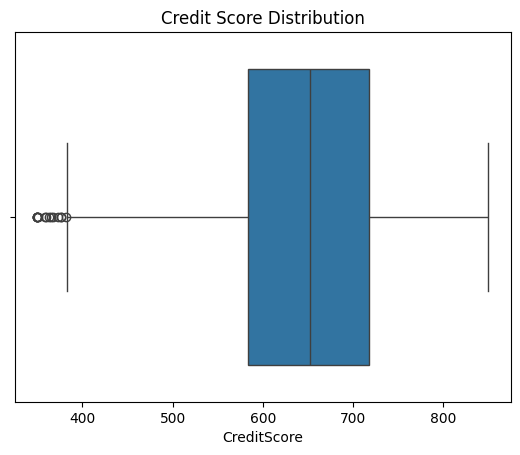

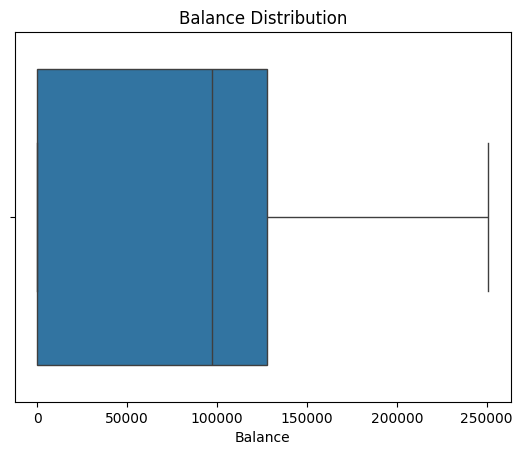

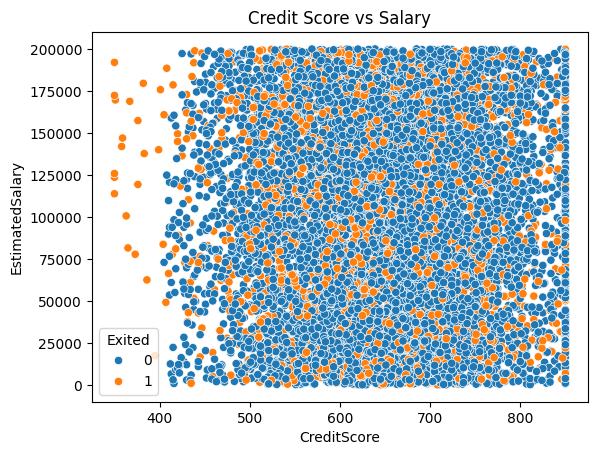

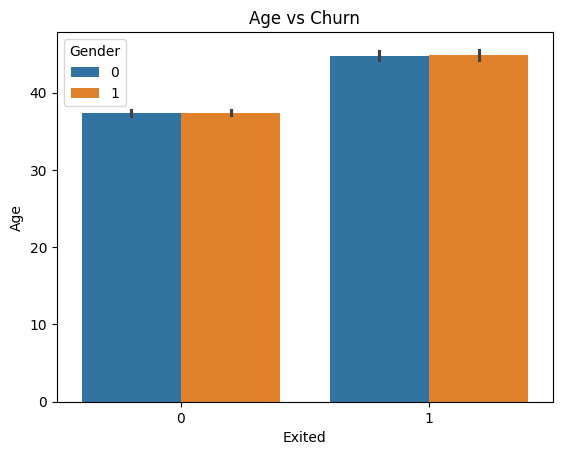

              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1607
           1       0.76      0.46      0.57       393

    accuracy                           0.87      2000
   macro avg       0.82      0.71      0.75      2000
weighted avg       0.86      0.87      0.85      2000



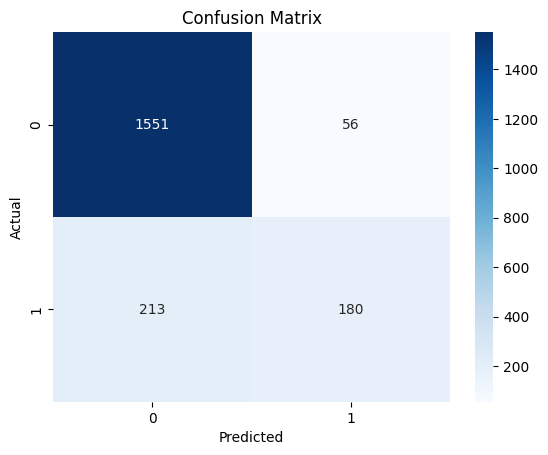

In [2]:
# Import Libraries
import kagglehub
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Download Dataset
path = kagglehub.dataset_download(
    "saurabhbadole/bank-customer-churn-prediction-dataset"
)

print("Dataset path:", path)
print(os.listdir(path))

# Load Dataset
file_path = os.path.join(path, "Churn_Modelling.csv")
df = pd.read_csv(file_path)

# Basic Exploration
print(df.head())
print(df.info())
print(df.describe())
print(df.isnull().sum())

# Data Cleaning
df.drop_duplicates(inplace=True)

# Encoding Categorical Variables
df["Geography"].replace({'France':0,'Germany':1,'Spain':2}, inplace=True)
df["Gender"].replace({'Female':0,'Male':1}, inplace=True)

# Data Visualization
sns.boxplot(x=df["CreditScore"])
plt.title("Credit Score Distribution")
plt.show()

sns.boxplot(x=df["Balance"])
plt.title("Balance Distribution")
plt.show()

sns.scatterplot(data=df, x="CreditScore", y="EstimatedSalary", hue="Exited")
plt.title("Credit Score vs Salary")
plt.show()

sns.barplot(data=df, x="Exited", y="Age", hue="Gender")
plt.title("Age vs Churn")
plt.show()

# Feature Selection
X = df.iloc[:,3:-1]
y = df["Exited"]

# Feature Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Train Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Random Forest Model
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=110,
    criterion="entropy",
    random_state=42
)

model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Model Evaluation
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()